In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Notebook 2
# Chest X-ray Data Preprocessing

This notebook prepares all datasets for model training.

Steps:
- Load metadata
- Clean reports
- Image preprocessing pipeline
- Tokenization
- Vocabulary creation
- Dataset creation
- DataLoader creation
  

In [1]:
import os
import re
import cv2
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from PIL import Image

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
# ===============================
# NIH
# ===============================

NIH_DIR = "/kaggle/input/datasets/biditdas06/nih-chestxray14"

NIH_CSV = os.path.join(
    NIH_DIR,
    "Data_Entry_2017_v2020.csv"
)

# ===============================
# IU-Xray
# ===============================

IU_DIR = "/kaggle/input/datasets/biditdas06/iu-x-ray"

IU_IMAGE_DIR = os.path.join(
    IU_DIR,
    "nlm_cxr_png"
)

IU_XML_DIR = os.path.join(
    IU_DIR,
    "nlm_cxr_reports",
    "ecgen-radiology"
)

# ===============================
# COVIDx
# ===============================

COVID_DIR = "/kaggle/input/datasets/andyczhao/covidx-cxr2"

COVID_TRAIN = os.path.join(COVID_DIR, "train.txt")
COVID_VAL = os.path.join(COVID_DIR, "val.txt")
COVID_TEST = os.path.join(COVID_DIR, "test.txt")

print("Dataset paths created.")

Dataset paths created.


In [3]:
OUTPUT_DIR = "/kaggle/working/preprocessed"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print(OUTPUT_DIR)

/kaggle/working/preprocessed


In [4]:
print("="*60)

print("NIH CSV Exists :",
      os.path.exists(NIH_CSV))

print("IU Images Exists :",
      os.path.exists(IU_IMAGE_DIR))

print("IU XML Exists :",
      os.path.exists(IU_XML_DIR))

print("COVID Train Exists :",
      os.path.exists(COVID_TRAIN))

print("="*60)

NIH CSV Exists : True
IU Images Exists : True
IU XML Exists : True
COVID Train Exists : True


In [5]:
nih_df = pd.read_csv(NIH_CSV)

covid_train = pd.read_csv(
    COVID_TRAIN,
    sep=" ",
    header=None,
    names=[
        "patient_id",
        "image_name",
        "label",
        "source"
    ]
)

covid_val = pd.read_csv(
    COVID_VAL,
    sep=" ",
    header=None,
    names=[
        "patient_id",
        "image_name",
        "label",
        "source"
    ]
)

covid_test = pd.read_csv(
    COVID_TEST,
    sep=" ",
    header=None,
    names=[
        "patient_id",
        "image_name",
        "label",
        "source"
    ]
)

print("Metadata Loaded!")

Metadata Loaded!


In [6]:
print("="*60)

print("NIH")

print(nih_df.shape)

print()

print("COVID Train")

print(covid_train.shape)

print()

print("COVID Validation")

print(covid_val.shape)

print()

print("COVID Test")

print(covid_test.shape)

print("="*60)

NIH
(112120, 11)

COVID Train
(67863, 4)

COVID Validation
(8473, 4)

COVID Test
(8482, 4)


In [7]:
iu_images = glob.glob(
    os.path.join(
        IU_IMAGE_DIR,
        "*.png"
    )
)

iu_xml = glob.glob(
    os.path.join(
        IU_XML_DIR,
        "*.xml"
    )
)

print("IU Images :", len(iu_images))

print("IU XML :", len(iu_xml))

IU Images : 7470
IU XML : 3955


In [8]:
print("="*60)

print("Notebook 2 Sanity Check")

print("="*60)

print("NIH Loaded :", len(nih_df))

print("IU Images :", len(iu_images))

print("IU Reports :", len(iu_xml))

print("COVID Train :", len(covid_train))

print("="*60)

Notebook 2 Sanity Check
NIH Loaded : 112120
IU Images : 7470
IU Reports : 3955
COVID Train : 67863


In [9]:
records = []

for xml_file in iu_xml:

    tree = ET.parse(xml_file)
    root = tree.getroot()

    image_name = ""
    findings = ""
    impression = ""

    # Image Name
    parent = root.find("parentImage")

    if parent is not None:
        image_name = parent.attrib.get("id", "") + ".png"

    # Article
    medline = root.find("MedlineCitation")

    if medline is not None:

        article = medline.find("Article")

        if article is not None:

            abstract = article.find("Abstract")

            if abstract is not None:

                for section in abstract.findall("AbstractText"):

                    label = section.attrib.get("Label", "")
                    text = section.text if section.text else ""

                    if label == "FINDINGS":
                        findings = text

                    elif label == "IMPRESSION":
                        impression = text

    records.append({
        "image_name": image_name,
        "findings": findings,
        "impression": impression
    })

print("Reports Parsed :", len(records))

Reports Parsed : 3955


In [10]:
iu_df = pd.DataFrame(records)

print(iu_df.shape)

iu_df.head()

(3955, 3)


,image_name,findings,impression
0,CXR3468_IM-1684-0001-0001.png,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...
1,CXR1853_IM-0555-1001.png,"The lungs are clear bilaterally. Specifically,...",No acute cardiopulmonary abnormality.
2,CXR1317_IM-0205-1001.png,Lungs are clear. There is minimal atelectasis ...,"Minimal atelectasis left base, no acute abnorm..."
3,CXR1159_IM-0107-1001.png,Lungs are clear. There is no pneumothorax or p...,No acute cardiopulmonary process.
4,CXR2803_IM-1234-1001.png,There are low lung volumes. The cardiac silhou...,No acute cardiopulmonary process.


In [11]:
iu_df = iu_df[
    (iu_df["findings"] != "") &
    (iu_df["impression"] != "")
]

iu_df.reset_index(drop=True, inplace=True)

print("Remaining Reports :", len(iu_df))

Remaining Reports : 3419


In [12]:
print("="*60)

print("Missing Findings :",
      (iu_df["findings"]=="").sum())

print("Missing Impression :",
      (iu_df["impression"]=="").sum())

print("Duplicate Reports :",
      iu_df.duplicated().sum())

print("="*60)

Missing Findings : 0
Missing Impression : 0
Duplicate Reports : 2


In [13]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"\n", " ", text)

    text = re.sub(r"\s+", " ", text)

    text = re.sub(r"[^a-z0-9., ]", "", text)

    return text.strip()

In [14]:
iu_df["findings"] = iu_df["findings"].apply(clean_text)

iu_df["impression"] = iu_df["impression"].apply(clean_text)

iu_df.head()

,image_name,findings,impression
0,CXR3468_IM-1684-0001-0001.png,heart size is at the upper limits of normal. t...,1. no focal airspace consolidation. 2. emphyse...
1,CXR1853_IM-0555-1001.png,"the lungs are clear bilaterally. specifically,...",no acute cardiopulmonary abnormality.
2,CXR1317_IM-0205-1001.png,lungs are clear. there is minimal atelectasis ...,"minimal atelectasis left base, no acute abnorm..."
3,CXR1159_IM-0107-1001.png,lungs are clear. there is no pneumothorax or p...,no acute cardiopulmonary process.
4,CXR2803_IM-1234-1001.png,there are low lung volumes. the cardiac silhou...,no acute cardiopulmonary process.


In [18]:
iu_df["report"] = (
    "<start> "
    + "findings: "
    + iu_df["findings"]
    + " impression: "
    + iu_df["impression"]
    + " <end>"
)

iu_df[["report"]].head()

,report
0,<start> findings: heart size is at the upper l...
1,<start> findings: the lungs are clear bilatera...
2,<start> findings: lungs are clear. there is mi...
3,<start> findings: lungs are clear. there is no...
4,<start> findings: there are low lung volumes. ...


In [19]:
iu_df[["image_name", "report"]].head()

,image_name,report
0,CXR3468_IM-1684-0001-0001.png,<start> findings: heart size is at the upper l...
1,CXR1853_IM-0555-1001.png,<start> findings: the lungs are clear bilatera...
2,CXR1317_IM-0205-1001.png,<start> findings: lungs are clear. there is mi...
3,CXR1159_IM-0107-1001.png,<start> findings: lungs are clear. there is no...
4,CXR2803_IM-1234-1001.png,<start> findings: there are low lung volumes. ...


In [20]:
iu_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "iu_reports_clean.csv"
    ),
    index=False
)

print("Clean reports saved!")

Clean reports saved!


In [21]:
from collections import Counter

word_counter = Counter()

for report in iu_df["report"]:
    word_counter.update(report.split())

print("Unique Words :", len(word_counter))

Unique Words : 2893


In [22]:
vocab = {
    "<pad>": 0,
    "<unk>": 1
}

for word in word_counter:
    vocab[word] = len(vocab)

print("Vocabulary Size :", len(vocab))

Vocabulary Size : 2895


In [23]:
idx2word = {
    idx: word
    for word, idx in vocab.items()
}

print("Reverse Vocabulary Created!")

Reverse Vocabulary Created!


In [24]:
iu_df["report_length"] = iu_df["report"].apply(
    lambda x: len(x.split())
)

iu_df["report_length"].describe()

count    3419.000000
mean       43.879497
std        20.329572
min        16.000000
25%        30.000000
50%        39.000000
75%        52.000000
max       234.000000
Name: report_length, dtype: float64

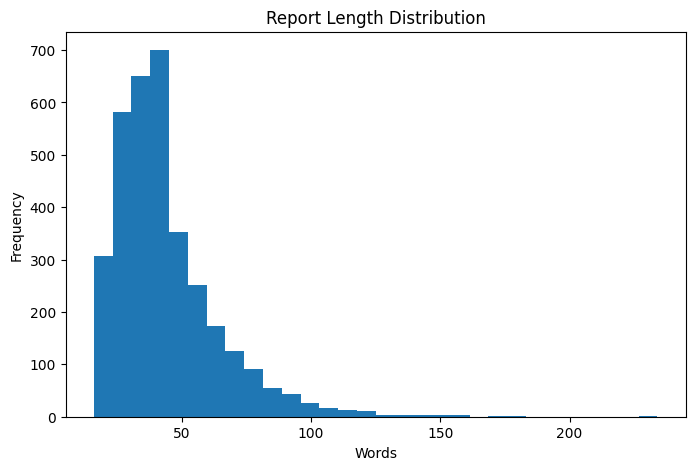

In [25]:
plt.figure(figsize=(8,5))

plt.hist(
    iu_df["report_length"],
    bins=30
)

plt.title("Report Length Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [26]:
MAX_LENGTH = 120

print("Maximum Report Length :", MAX_LENGTH)

Maximum Report Length : 120


In [27]:
def tokenize(report):

    tokens = []

    for word in report.split():

        tokens.append(
            vocab.get(
                word,
                vocab["<unk>"]
            )
        )

    return tokens


iu_df["tokens"] = iu_df["report"].apply(
    tokenize
)

iu_df.head()

,image_name,findings,impression,report,report_length,tokens
0,CXR3468_IM-1684-0001-0001.png,heart size is at the upper limits of normal. t...,1. no focal airspace consolidation. 2. emphyse...,<start> findings: heart size is at the upper l...,64,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 6, 14..."
1,CXR1853_IM-0555-1001.png,"the lungs are clear bilaterally. specifically,...",no acute cardiopulmonary abnormality.,<start> findings: the lungs are clear bilatera...,37,"[2, 3, 8, 18, 21, 49, 50, 51, 28, 52, 11, 30, ..."
2,CXR1317_IM-0205-1001.png,lungs are clear. there is minimal atelectasis ...,"minimal atelectasis left base, no acute abnorm...",<start> findings: lungs are clear. there is mi...,52,"[2, 3, 18, 21, 67, 13, 6, 68, 69, 70, 8, 71, 7..."
3,CXR1159_IM-0107-1001.png,lungs are clear. there is no pneumothorax or p...,no acute cardiopulmonary process.,<start> findings: lungs are clear. there is no...,30,"[2, 3, 18, 21, 67, 13, 6, 28, 92, 55, 34, 35, ..."
4,CXR2803_IM-1234-1001.png,there are low lung volumes. the cardiac silhou...,no acute cardiopulmonary process.,<start> findings: there are low lung volumes. ...,34,"[2, 3, 13, 21, 96, 97, 98, 8, 99, 100, 9, 93, ..."


In [28]:
def pad_sequence(tokens):

    if len(tokens) > MAX_LENGTH:
        tokens = tokens[:MAX_LENGTH]

    else:
        tokens = tokens + [
            vocab["<pad>"]
        ] * (
            MAX_LENGTH - len(tokens)
        )

    return tokens


iu_df["tokens"] = iu_df["tokens"].apply(
    pad_sequence
)

In [29]:
print(iu_df["tokens"][0][:30])

print()

print("Sequence Length :",
      len(iu_df["tokens"][0]))

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 6, 14, 15, 16, 17, 8, 18, 19, 20, 13, 21, 22, 23, 24, 25, 8, 26, 27]

Sequence Length : 120


In [30]:
import pickle

with open(
    os.path.join(
        OUTPUT_DIR,
        "vocab.pkl"
    ),
    "wb"
) as f:

    pickle.dump(vocab, f)

print("Vocabulary Saved!")

Vocabulary Saved!


In [31]:
iu_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "iu_processed_reports.csv"
    ),
    index=False
)

print("Processed Reports Saved!")

Processed Reports Saved!


In [32]:
!pip -q install transformers

In [33]:
from transformers import AutoTokenizer

In [34]:
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully!")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer Loaded Successfully!


In [35]:
encoded_reports = tokenizer(
    iu_df["report"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print(encoded_reports.keys())

KeysView({'input_ids': tensor([[ 101,  133, 1838,  ...,  133, 1322,  102],
        [ 101,  133, 1838,  ...,    0,    0,    0],
        [ 101,  133, 1838,  ...,    0,    0,    0],
        ...,
        [ 101,  133, 1838,  ...,    0,    0,    0],
        [ 101,  133, 1838,  ...,    0,    0,    0],
        [ 101,  133, 1838,  ...,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})


In [37]:
iu_df["input_ids"] = encoded_reports["input_ids"].tolist()

iu_df["attention_mask"] = encoded_reports["attention_mask"].tolist()

iu_df.head()

,image_name,findings,impression,report,report_length,tokens,input_ids,attention_mask
0,CXR3468_IM-1684-0001-0001.png,heart size is at the upper limits of normal. t...,1. no focal airspace consolidation. 2. emphyse...,<start> findings: heart size is at the upper l...,64,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 6, 14...","[101, 133, 1838, 135, 9505, 131, 1762, 2060, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,CXR1853_IM-0555-1001.png,"the lungs are clear bilaterally. specifically,...",no acute cardiopulmonary abnormality.,<start> findings: the lungs are clear bilatera...,37,"[2, 3, 8, 18, 21, 49, 50, 51, 28, 52, 11, 30, ...","[101, 133, 1838, 135, 9505, 131, 1103, 8682, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,CXR1317_IM-0205-1001.png,lungs are clear. there is minimal atelectasis ...,"minimal atelectasis left base, no acute abnorm...",<start> findings: lungs are clear. there is mi...,52,"[2, 3, 18, 21, 67, 13, 6, 68, 69, 70, 8, 71, 7...","[101, 133, 1838, 135, 9505, 131, 8682, 1132, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,CXR1159_IM-0107-1001.png,lungs are clear. there is no pneumothorax or p...,no acute cardiopulmonary process.,<start> findings: lungs are clear. there is no...,30,"[2, 3, 18, 21, 67, 13, 6, 28, 92, 55, 34, 35, ...","[101, 133, 1838, 135, 9505, 131, 8682, 1132, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,CXR2803_IM-1234-1001.png,there are low lung volumes. the cardiac silhou...,no acute cardiopulmonary process.,<start> findings: there are low lung volumes. ...,34,"[2, 3, 13, 21, 96, 97, 98, 8, 99, 100, 9, 93, ...","[101, 133, 1838, 135, 9505, 131, 1175, 1132, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [38]:
print("Original Report:\n")
print(iu_df["report"][0])

print("\nToken IDs:\n")
print(iu_df["input_ids"][0][:30])

print("\nAttention Mask:\n")
print(iu_df["attention_mask"][0][:30])

Original Report:

<start> findings: heart size is at the upper limits of normal. there is aortic atherosclerotic vascular calcification. the lungs remain hyperexpanded. there are biapical opacities, stable from the prior study. no xxxx focal airspace consolidation. no significant pleural effusion. no pneumothorax. there are mild degenerative changes of the spine. impression: 1. no focal airspace consolidation. 2. emphysema. 3. stable biapical opacities, possibly scarring. <end>

Token IDs:

[101, 133, 1838, 135, 9505, 131, 1762, 2060, 1110, 1120, 1103, 3105, 6263, 1104, 2999, 119, 1175, 1110, 170, 12148, 1596, 1120, 4679, 2155, 10536, 10595, 1596, 26557, 11019, 1233]

Attention Mask:

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [39]:
train_df, val_df = train_test_split(
    iu_df,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 3077
Validation: 342


In [40]:
train_df.to_csv(
    os.path.join(OUTPUT_DIR, "train_reports.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(OUTPUT_DIR, "val_reports.csv"),
    index=False
)

print("Processed reports saved!")

Processed reports saved!


In [41]:
print(os.listdir(OUTPUT_DIR))

['val_reports.csv', 'vocab.pkl', 'train_reports.csv', 'iu_reports_clean.csv', 'iu_processed_reports.csv']


In [42]:
IMG_SIZE = 224

def preprocess_image(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return None

    # BGR → RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # CLAHE
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Normalize
    image = image.astype(np.float32) / 255.0

    return image

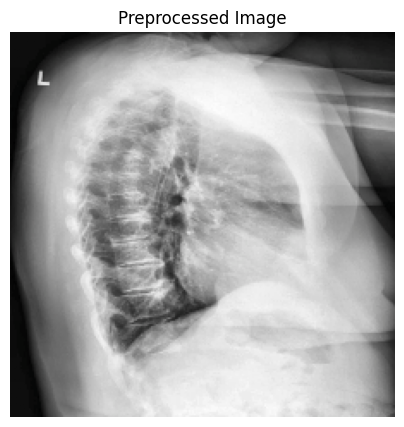

In [43]:
sample_image = iu_images[0]

image = preprocess_image(sample_image)

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")
plt.title("Preprocessed Image")
plt.show()

In [44]:
image_dict = {}

for img in iu_images:
    image_dict[os.path.basename(img)] = img

print("Images Indexed :", len(image_dict))

Images Indexed : 7470


In [46]:
iu_df["image_path"] = iu_df["image_name"].map(image_dict)

iu_df.head()

,image_name,findings,impression,report,report_length,tokens,input_ids,attention_mask,image_path
0,CXR3468_IM-1684-0001-0001.png,heart size is at the upper limits of normal. t...,1. no focal airspace consolidation. 2. emphyse...,<start> findings: heart size is at the upper l...,64,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 6, 14...","[101, 133, 1838, 135, 9505, 131, 1762, 2060, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...
1,CXR1853_IM-0555-1001.png,"the lungs are clear bilaterally. specifically,...",no acute cardiopulmonary abnormality.,<start> findings: the lungs are clear bilatera...,37,"[2, 3, 8, 18, 21, 49, 50, 51, 28, 52, 11, 30, ...","[101, 133, 1838, 135, 9505, 131, 1103, 8682, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...
2,CXR1317_IM-0205-1001.png,lungs are clear. there is minimal atelectasis ...,"minimal atelectasis left base, no acute abnorm...",<start> findings: lungs are clear. there is mi...,52,"[2, 3, 18, 21, 67, 13, 6, 68, 69, 70, 8, 71, 7...","[101, 133, 1838, 135, 9505, 131, 8682, 1132, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...
3,CXR1159_IM-0107-1001.png,lungs are clear. there is no pneumothorax or p...,no acute cardiopulmonary process.,<start> findings: lungs are clear. there is no...,30,"[2, 3, 18, 21, 67, 13, 6, 28, 92, 55, 34, 35, ...","[101, 133, 1838, 135, 9505, 131, 8682, 1132, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...
4,CXR2803_IM-1234-1001.png,there are low lung volumes. the cardiac silhou...,no acute cardiopulmonary process.,<start> findings: there are low lung volumes. ...,34,"[2, 3, 13, 21, 96, 97, 98, 8, 99, 100, 9, 93, ...","[101, 133, 1838, 135, 9505, 131, 1175, 1132, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",/kaggle/input/datasets/biditdas06/iu-x-ray/nlm...


In [47]:
print(
    "Missing Images :",
    iu_df["image_path"].isnull().sum()
)

Missing Images : 88


In [48]:
missing = iu_df[iu_df["image_path"].isnull()]

print("Missing Images:", len(missing))

missing[["image_name"]].head(20)

Missing Images: 88


,image_name
11,
77,
84,
111,
198,
283,
284,
330,
343,
430,


In [49]:
print("Empty image names:",
      (iu_df["image_name"] == "").sum())

Empty image names: 88


In [50]:
iu_df = iu_df[iu_df["image_name"] != ""].reset_index(drop=True)

print(len(iu_df))

3331


In [60]:
print(
    "Missing Images :",
    iu_df["image_path"].isnull().sum()
)

Missing Images : 0


In [51]:
iu_df["image_path"] = iu_df["image_name"].map(image_dict)

print(iu_df["image_path"].isnull().sum())

0


In [55]:
train_df, val_df = train_test_split(
    iu_df,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

In [56]:
class IUReportDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = preprocess_image(
            row["image_path"]
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2,0,1)

        return {
            "image": image,
            "report": row["report"]
        }

In [57]:
train_dataset = IUReportDataset(train_df)

val_dataset = IUReportDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [58]:
batch = next(iter(train_loader))

print(batch["image"].shape)

print(len(batch["report"]))

torch.Size([16, 3, 224, 224])
16


In [59]:
train_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "train_final.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "val_final.csv"
    ),
    index=False
)

print("Notebook 2 Completed Successfully!")

Notebook 2 Completed Successfully!


In [61]:
import os

print("="*60)
print("NOTEBOOK 2 FINAL VERIFICATION")
print("="*60)

print("\nOutput Files:")

for file in sorted(os.listdir(OUTPUT_DIR)):
    print("✅", file)

print("\nTrain Samples :", len(train_df))
print("Validation Samples :", len(val_df))

print("\nNotebook 2 Completed Successfully!")

NOTEBOOK 2 FINAL VERIFICATION

Output Files:
✅ iu_processed_reports.csv
✅ iu_reports_clean.csv
✅ train_final.csv
✅ train_reports.csv
✅ val_final.csv
✅ val_reports.csv
✅ vocab.pkl

Train Samples : 2997
Validation Samples : 334

Notebook 2 Completed Successfully!
